## Author
Name: Zhihao Cui <br>
Institute: School of Mathematics and Statistics <br>
No: 20233002662

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, cut_tree

In [9]:
# step1 读取与初步理解数据
retail = pd.read_csv('OnlineRetail.csv', sep=",", encoding="ISO-8859-1", header=0)
print(retail.head())
print(retail.shape)
print(retail.info())
print(retail.describe())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  
(541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -

In [10]:
# step2 数据清洗
# 查看缺失值比例
df_null = round(100 * (retail.isnull().sum()) / len(retail), 2)
print(df_null)

# 删除含缺失值的行（主要影响 CustomerID 和 Description）
retail = retail.dropna()
print(retail.shape)

# CustomerID 转为字符串类型，便于分组
retail['CustomerID'] = retail['CustomerID'].astype(str)

InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64
(406829, 8)


In [11]:
# step3 准备 RFM 特征
# 3.1 交易金额（Monetary）
retail['Amount'] = retail['Quantity'] * retail['UnitPrice']

# 按客户汇总总金额
rfm_m = retail.groupby('CustomerID')['Amount'].sum().reset_index()
print(rfm_m.head())

# 3.2 交易频率（Frequency）：使用唯一发票号计数（修复原 count 错误）
rfm_f = retail.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
rfm_f.columns = ['CustomerID', 'Frequency']
print(rfm_f.head())

# 合并 Monetary 与 Frequency
rfm = pd.merge(rfm_m, rfm_f, on='CustomerID', how='inner')
print(rfm.head())

# 3.3 最近消费时间（Recency）
# 转换日期字段格式
retail['InvoiceDate'] = pd.to_datetime(retail['InvoiceDate'], format='%d-%m-%Y %H:%M')
max_date = max(retail['InvoiceDate'])                     # 数据集中的最晚日期
retail['Diff'] = max_date - retail['InvoiceDate']         # 距离最晚日期的天数差

# 每个客户的最小天数差（即最后一次购买距今的天数）
rfm_p = retail.groupby('CustomerID')['Diff'].min().reset_index()
rfm_p['Diff'] = rfm_p['Diff'].dt.days                     # 提取天数数值
rfm_p.columns = ['CustomerID', 'Recency']

# 合并 Recency 到 RFM 表
rfm = pd.merge(rfm, rfm_p, on='CustomerID', how='inner')
print(rfm.head())

  CustomerID   Amount
0    12346.0     0.00
1    12347.0  4310.00
2    12348.0  1797.24
3    12349.0  1757.55
4    12350.0   334.40
  CustomerID  Frequency
0    12346.0          2
1    12347.0          7
2    12348.0          4
3    12349.0          1
4    12350.0          1
  CustomerID   Amount  Frequency
0    12346.0     0.00          2
1    12347.0  4310.00          7
2    12348.0  1797.24          4
3    12349.0  1757.55          1
4    12350.0   334.40          1
  CustomerID   Amount  Frequency  Recency
0    12346.0     0.00          2      325
1    12347.0  4310.00          7        1
2    12348.0  1797.24          4       74
3    12349.0  1757.55          1       18
4    12350.0   334.40          1      309


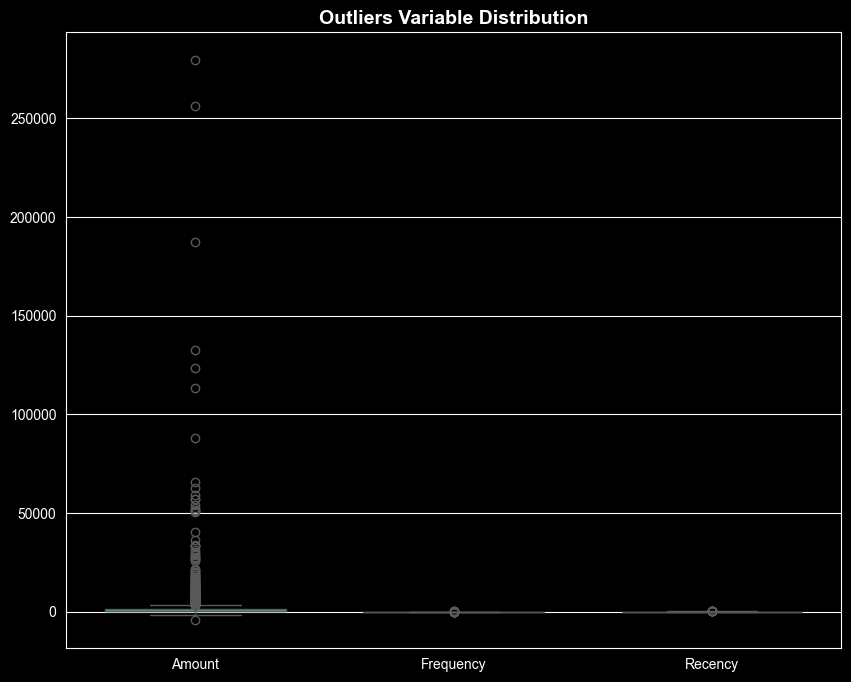

In [12]:
# 异常值处理（使用 5% 与 95% 分位数 + 1.5 IQR 规则）
# 可视化异常分布
attributes = ['Amount', 'Frequency', 'Recency']
plt.rcParams['figure.figsize'] = [10, 8]
sns.boxplot(data=rfm[attributes], orient="v", palette="Set2", whis=1.5, saturation=1, width=0.7)
plt.title("Outliers Variable Distribution", fontsize=14, fontweight='bold')
plt.show()

# 分别对三个字段剔除异常值
for col in ['Amount', 'Recency', 'Frequency']:
    Q1 = rfm[col].quantile(0.05)
    Q3 = rfm[col].quantile(0.95)
    IQR = Q3 - Q1
    rfm = rfm[(rfm[col] >= Q1 - 1.5*IQR) & (rfm[col] <= Q3 + 1.5*IQR)]

In [13]:
# 特征标准化（均值为0，方差为1）
rfm_df = rfm[['Amount', 'Frequency', 'Recency']]
scaler = StandardScaler()
rfm_df_scaled = scaler.fit_transform(rfm_df)
rfm_df_scaled = pd.DataFrame(rfm_df_scaled, columns=['Amount', 'Frequency', 'Recency'])
print(rfm_df_scaled.head())

     Amount  Frequency   Recency
0 -0.731289  -0.485145  2.303661
1  1.760755   0.584266 -0.906294
2  0.307876  -0.057381 -0.183063
3  0.284927  -0.699027 -0.737870
4 -0.537939  -0.699027  2.145145


[2 3 0 ... 0 3 0]


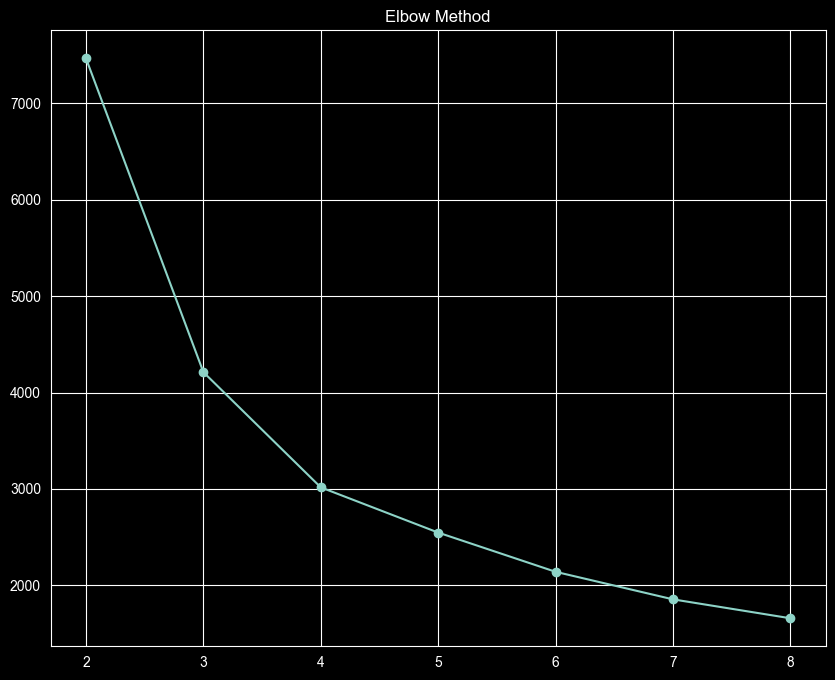

For n_clusters=2, silhouette score = 0.5410
For n_clusters=3, silhouette score = 0.5092
For n_clusters=4, silhouette score = 0.4821
For n_clusters=5, silhouette score = 0.4377
For n_clusters=6, silhouette score = 0.4160
For n_clusters=7, silhouette score = 0.4166
For n_clusters=8, silhouette score = 0.3768
  CustomerID   Amount  Frequency  Recency  Cluster_Id
0    12346.0     0.00          2      325           1
1    12347.0  4310.00          7        1           2
2    12348.0  1797.24          4       74           0
3    12349.0  1757.55          1       18           0
4    12350.0   334.40          1      309           1


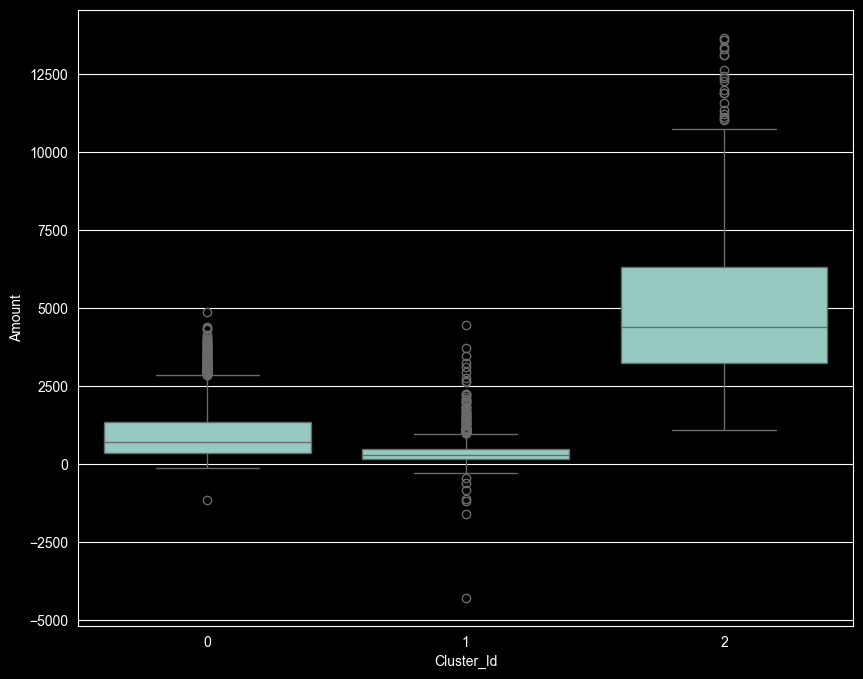

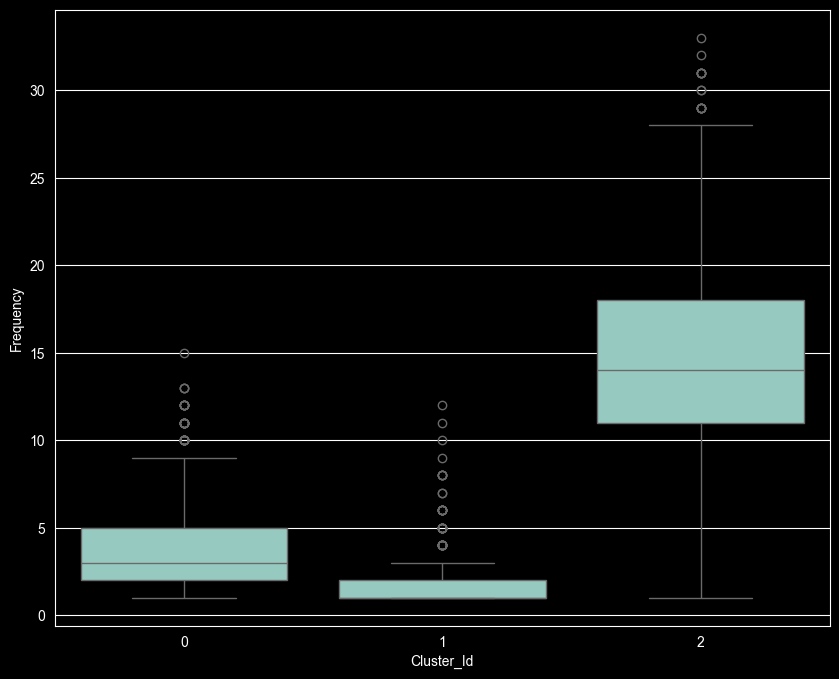

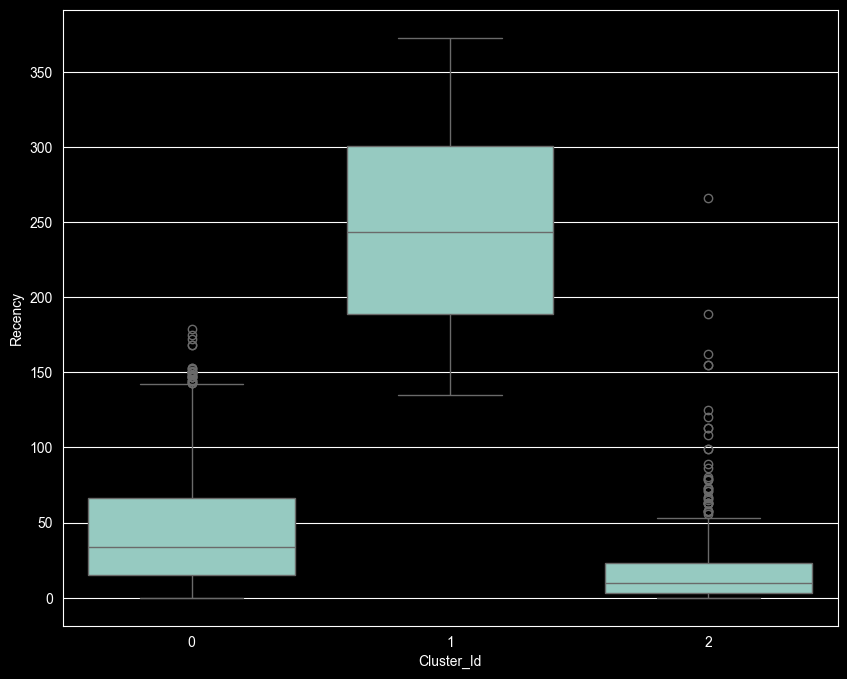

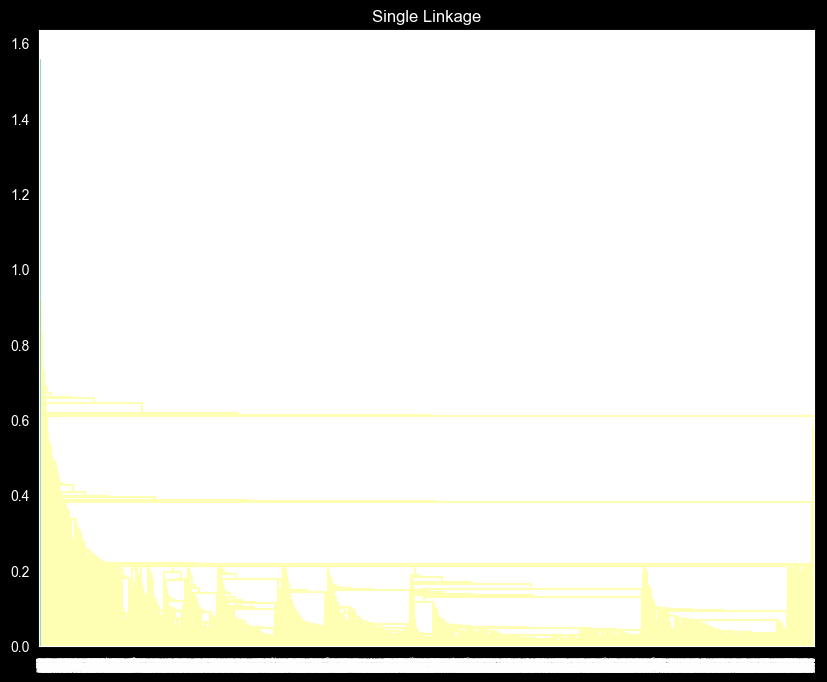

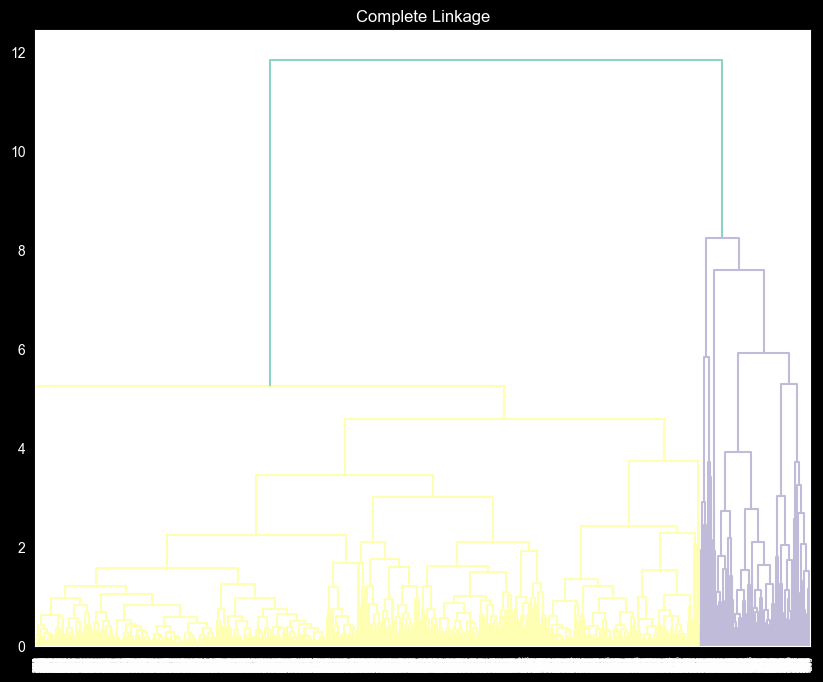

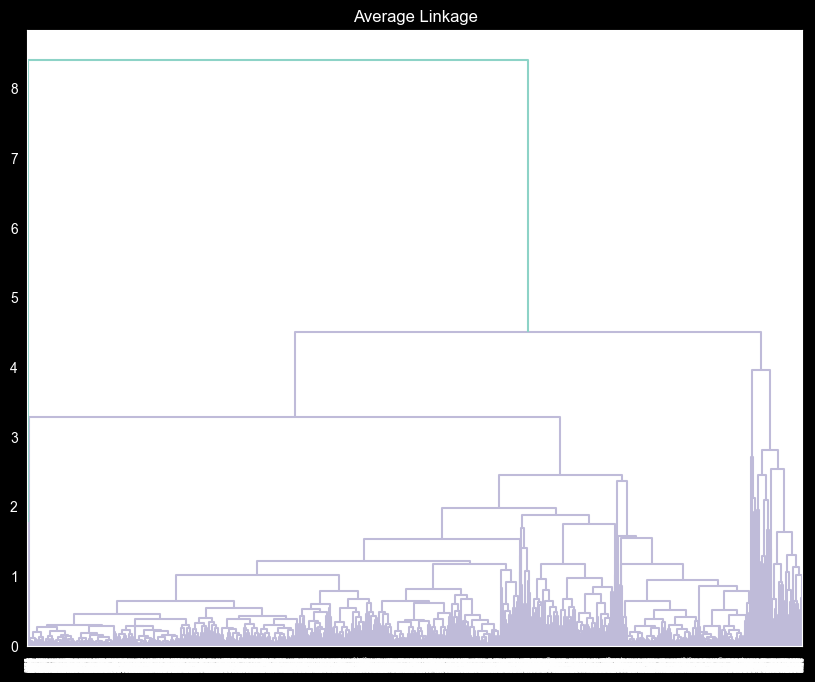

  CustomerID   Amount  Frequency  Recency  Cluster_Id  Cluster_Labels
0    12346.0     0.00          2      325           1               0
1    12347.0  4310.00          7        1           2               0
2    12348.0  1797.24          4       74           0               0
3    12349.0  1757.55          1       18           0               0
4    12350.0   334.40          1      309           1               0


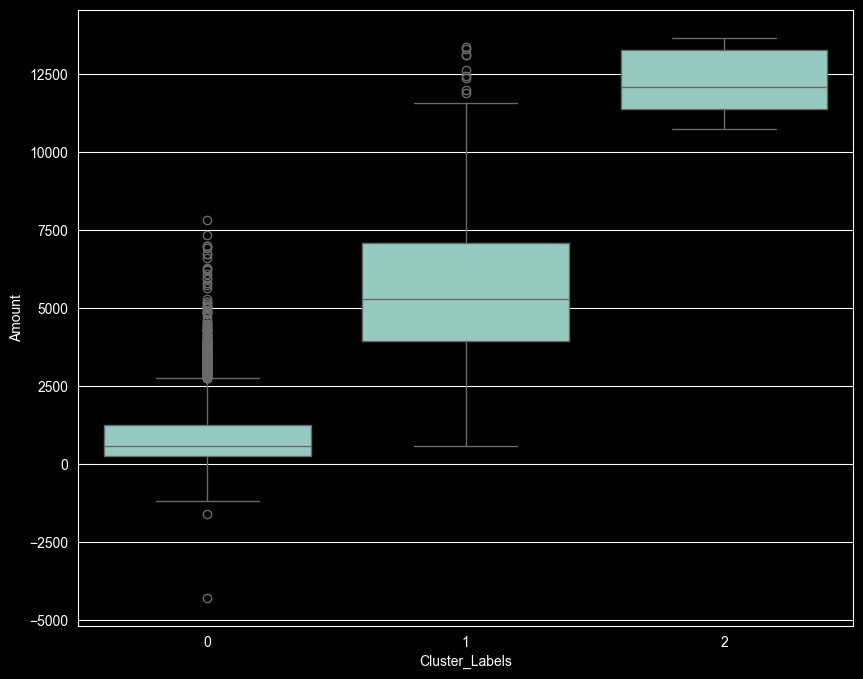

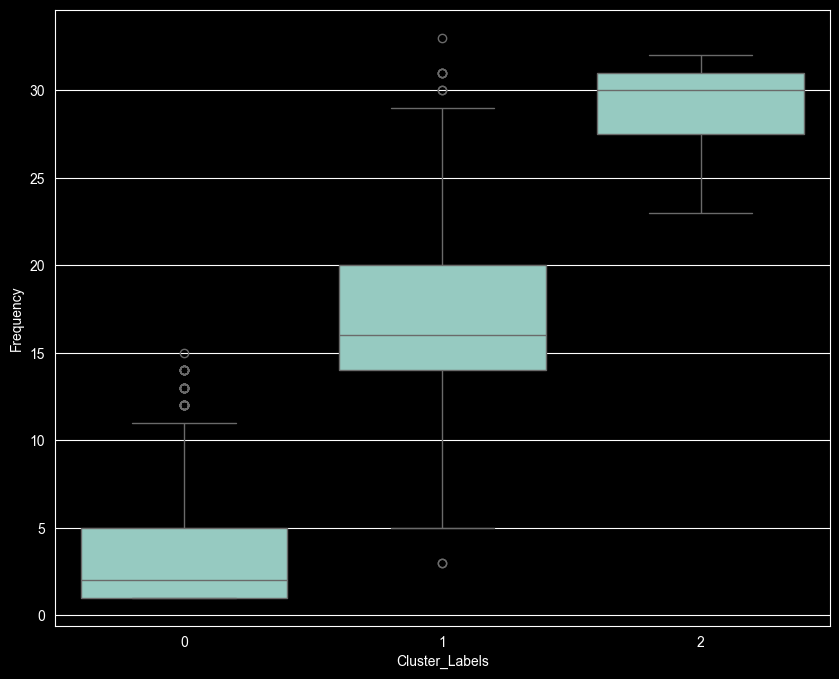

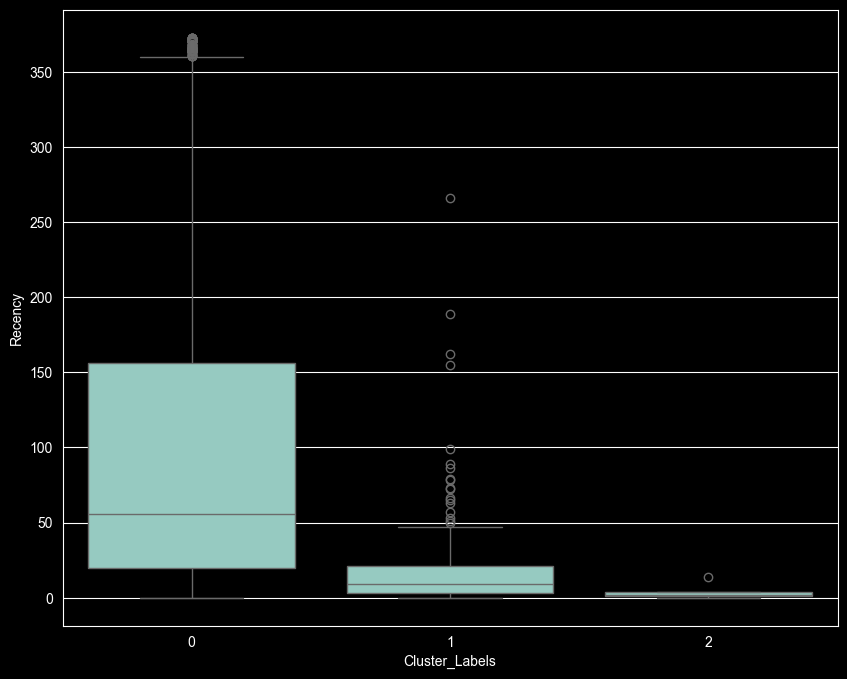

In [14]:
# step4 聚类建模
# ---------- 4.1 K-means 聚类 ----------
# 初步尝试 k=4
kmeans = KMeans(n_clusters=4, max_iter=50, random_state=42, n_init=10)
kmeans.fit(rfm_df_scaled)
print(kmeans.labels_)

# 肘部法则：计算不同 k 的簇内平方和（SSD/ inertia）
ssd = []
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50, random_state=42, n_init=10)
    kmeans.fit(rfm_df_scaled)
    ssd.append(kmeans.inertia_)
plt.plot(range_n_clusters, ssd, marker='o')
plt.title("Elbow Method")
plt.show()

# 轮廓系数：评估聚类质量（越接近1越好）
for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(rfm_df_scaled)
    sil = silhouette_score(rfm_df_scaled, cluster_labels)
    print(f"For n_clusters={num_clusters}, silhouette score = {sil:.4f}")

# 选择 k=3 作为最终模型
kmeans = KMeans(n_clusters=3, max_iter=50, random_state=42, n_init=10)
rfm['Cluster_Id'] = kmeans.fit_predict(rfm_df_scaled)
print(rfm.head())

# 可视化不同簇在 Amount / Frequency / Recency 上的分布
sns.boxplot(x='Cluster_Id', y='Amount', data=rfm)
plt.show()
sns.boxplot(x='Cluster_Id', y='Frequency', data=rfm)
plt.show()
sns.boxplot(x='Cluster_Id', y='Recency', data=rfm)
plt.show()

# ---------- 4.2 层次聚类 ----------
# 分别展示 single linkage, complete linkage, average linkage 的树状图
# 单链接（最短距离）
mergings_single = linkage(rfm_df_scaled, method="single", metric='euclidean')
dendrogram(mergings_single)
plt.title("Single Linkage")
plt.show()

# 全链接（最长距离）
mergings_complete = linkage(rfm_df_scaled, method="complete", metric='euclidean')
dendrogram(mergings_complete)
plt.title("Complete Linkage")
plt.show()

# 平均链接
mergings_avg = linkage(rfm_df_scaled, method="average", metric='euclidean')
dendrogram(mergings_avg)
plt.title("Average Linkage")
plt.show()

# 基于平均链接的树状图切分为 3 个簇
cluster_labels = cut_tree(mergings_avg, n_clusters=3).reshape(-1, )
rfm['Cluster_Labels'] = cluster_labels
print(rfm.head())

# 可视化层次聚类的结果
sns.boxplot(x='Cluster_Labels', y='Amount', data=rfm)
plt.show()
sns.boxplot(x='Cluster_Labels', y='Frequency', data=rfm)
plt.show()
sns.boxplot(x='Cluster_Labels', y='Recency', data=rfm)
plt.show()